In [40]:
using SpecialFunctions
using ImmersedLayers
using Plots

In [36]:
Re = 40
γ = (im*Re)^(1/2)
C = hankelh1(2, γ) / hankelh1(0, γ);

In [101]:
# Ψ11(r) = -r - C./r # cylinder frame
Ψ11(r) = - C./r # inertial frame
Ψ12(r) = 2*hankelh1.(1,γ*r)/(γ*hankelh1(0, γ))
Ψ1(r) = Ψ11(r) + Ψ12(r)

#Ψ11r(r) = -1 + C./r.^2 # cylinder frame
Ψ11r(r) = C./r.^2 # inertial frame
Ψ12r(r) = 1/hankelh1(0, γ)*(hankelh1.(0,γ*r)-hankelh1.(2,γ*r))
Ψ1r(r) = Ψ11r.(r) + Ψ12r.(r)

U_r1(r) = Ψ1.(r) ./ r; # Ψ1 / r
U_θ1(r) = -Ψ1r.(r)

Ψ11rr(r) = -2 * C./r.^3
Ψ12rr(r) = -γ / (2*hankelh1(0, γ)) * (3*hankelh1.(1,γ*r)-hankelh1.(3,γ*r))
Ψ1rr(r) = Ψ11rr(r) + Ψ12rr(r)

Ψ11rrr(r) = 6 * C./r.^4
Ψ12rrr(r) = -γ^2 / (4*hankelh1(0, γ)) * (3 * hankelh1.(0, γ*r) - 4 * hankelh1.(2, γ*r) + hankelh1.(4, γ*r))
Ψ1rrr(r) = Ψ11rrr(r) + Ψ12rrr(r)

Ψ1rrr (generic function with 1 method)

In [96]:
r_test = 0.75:0.01:2

0.75:0.01:2.0

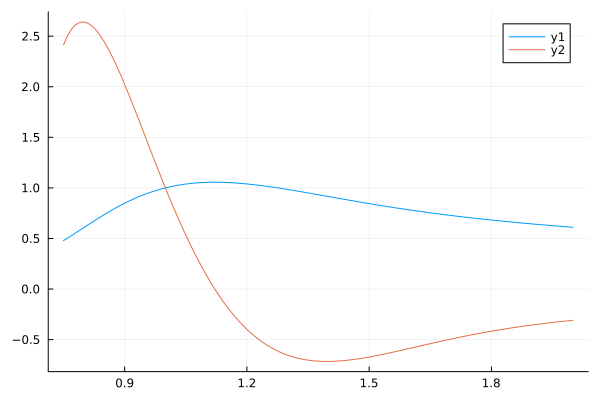

In [97]:
plot(r_test, real(Ψ1.(r_test)))
plot!(r_test, real(Ψ1r.(r_test)))
# plot!(r_test, real(Ψ1rr.(r_test)))

In [98]:
dUr1_dr(r) = 1 ./ r.^2 .* (Ψ1r.(r) .* r - Ψ1.(r)) 
dUθ1_dr(r) = - Ψ1rr.(r)

dUθ1_dr (generic function with 1 method)

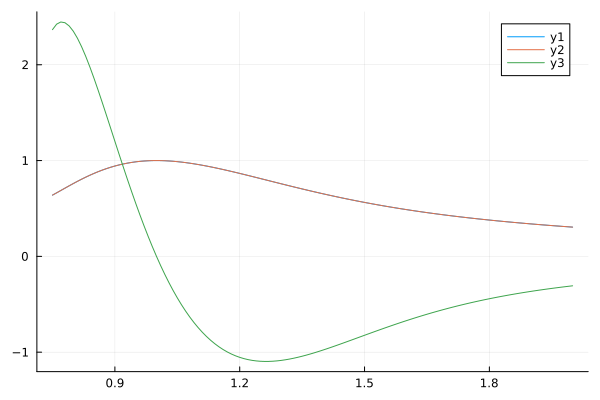

In [99]:
plot(r_test, real(U_r1.(r_test)))
plot!(r_test, real(Ψ1.(r_test) ./ r_test))
plot!(r_test, real(dUr1_dr.(r_test)))

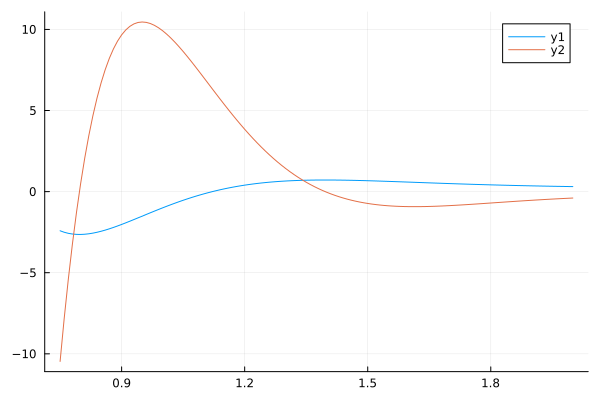

In [103]:
plot(r_test, real(U_θ1.(r_test)))
# plot!(r_test, -real(Ψ1r.(r_test)))
plot!(r_test, real(dUθ1_dr.(r_test)))

In [104]:
vdv_r(r, θ) = conj.(U_r1.(r)) .* dUr1_dr.(r) .* cos.(θ).^2 .-
conj.(U_θ1.(r)) ./ r .* U_r1.(r) .* sin.(θ).^2 .-
conj.(U_θ1.(r)) .* U_θ1.(r) ./ r .* sin.(θ).^2

vdv_r (generic function with 1 method)

In [105]:
vdv_θ(r, θ) = conj.(U_r1.(r)) .* dUθ1_dr.(r) .* cos.(θ) .* sin.(θ) .+
conj.(U_θ1.(r)) ./ r .* U_θ1.(r) .* cos.(θ) .* sin.(θ) .+
conj.(U_θ1.(r)) .* U_r1.(r) ./ r .* cos.(θ) .* sin.(θ)

vdv_θ (generic function with 1 method)

In [106]:
vdv_u(r, θ) = vdv_r.(r, θ) .* cos.(θ) - vdv_θ.(r, θ) .* sin.(θ)
vdv_v(r, θ) = vdv_r.(r, θ) .* sin.(θ) + vdv_θ.(r, θ) .* cos.(θ)

vdv_v (generic function with 1 method)

In [107]:
vdv_u_xy(x, y) = vdv_u(sqrt.(x.^2+y.^2), atan.(y,x))
vdv_v_xy(x, y) = vdv_v(sqrt.(x.^2+y.^2), atan.(y,x))

vdv_v_xy (generic function with 1 method)

In [111]:
vdv_u_exact = vdv_u.(X, Y);

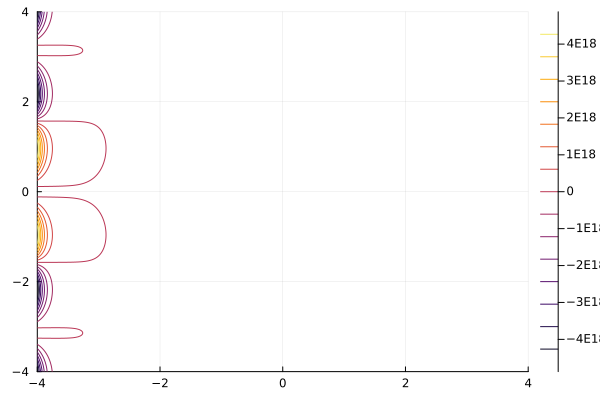

In [112]:
plot(x_g, y_g, real(vdv_u_exact))